# Phase 3 — Step 3: The Standard Router Baseline

## Objective

Phase 3 Step 2 built a cognitive Router-Index: a ChromaDB collection containing one **KSP-embedding per document**. Query routing is a vector lookup: cost is O(log N) and latency is a handful of milliseconds independent of corpus size.

The classical alternative — still widely shipped by LangChain's `MultiRetrievalQAChain` and similar libraries — is a **LLM-as-router**: you describe every collection in natural language inside the prompt and ask the LLM *"which one should I search?"*. This notebook implements that baseline so we can show concretely what it costs.

## What we measure

For every query:
- **Routing latency** — how many seconds the LLM takes to return a collection name (no actual retrieval happens yet).
- **Context bloat** — how many input tokens the routing prompt consumes (base prompt + concatenated collection descriptions). This is the scaling liability.
- **Routing correctness** — does the LLM pick the right department? Does it hallucinate a non-existent collection? Does it break on queries that genuinely span two departments?

We also run the same 10 queries through the **embedding-based Router B** from Step 2 (at document granularity, collapsed to the document's department) to keep the comparison apples-to-apples.

## What we want to conclude

Show three things:
1. The Standard LLM Router is **orders of magnitude slower** than the embedding router for the same accuracy (and sometimes lower accuracy on ambiguous queries).
2. The prompt cost grows **linearly with the number of departments**. Extrapolate to 25 / 50 / 100 collections and show where the Llama 3.2 context window breaks.
3. Even at the current size (5 departments), the LLM occasionally hallucinates or confidently picks the wrong collection — failure modes that the embedding approach does not have.

In [1]:
# Cell 1 — Imports, Ollama, embedding model, ChromaDB client
import json, os, re, time, statistics
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import requests
import chromadb
from langchain_huggingface import HuggingFaceEmbeddings
import matplotlib.pyplot as plt

BASE         = os.path.dirname(os.path.abspath("__file__"))
PH2_CHUNKS   = os.path.join(BASE, "..", "..", "data", "results", "notebook_results", "ph2", "ph2_plus_augmented_chunks.json")
STEP2_JSON   = os.path.join(BASE, "..", "..", "data", "results", "notebook_results", "ph3", "ph3_step2_ingestion_agent.json")
RESULTS_DIR  = os.path.join(BASE, "..", "..", "data", "results", "notebook_results", "ph3")
os.makedirs(RESULTS_DIR, exist_ok=True)

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL      = "llama3.2"

r = requests.get("http://localhost:11434/api/tags", timeout=5)
assert any(MODEL in m["name"] for m in r.json()["models"])
print(f"Ollama ready. Model: {MODEL}")

embed = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2", model_kwargs={"device": "cpu"})
chroma = chromadb.Client()
print("Embedding model + ChromaDB ready.")

Ollama ready. Model: llama3.2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Embedding model + ChromaDB ready.


## Cell 2 — Define 5 departmental collections + verbose descriptions

We map the 23 documents of the augmented corpus into 5 realistic departmental collections (HR, IT, Finance, Legal, Operations). Each collection gets a **verbose description** (2–4 sentences, 300–500 characters) of the sort a LangChain `MultiRetrievalQAChain` user would write. These descriptions are the prompt payload that inflates with every new department you add.

The 5 ChromaDB collections are created in-memory. The Standard LLM Router never actually *queries* these collections — it only picks a name based on the descriptions. The collections are there to show that the architecture is real.

In [2]:
# Cell 2 — Department definitions

# Collection name -> (verbose description, list of source documents)
COLLECTIONS: dict[str, dict] = {
    "HR": {
        "description": (
            "Human Resources collection. Contains the authoritative employee directory "
            "with personal identification numbers, emails, and roles; the new-hire "
            "onboarding guide with first-day procedures and building contacts; and the "
            "internal salary bands and compensation structure for every department. "
            "Use this collection for questions about personnel records, pay ranges, "
            "onboarding steps, and who-is-who inside the company."
        ),
        "documents": [
            "hr_employee_directory.txt",
            "hr_onboarding_guide.md",
            "hr_salary_bands_2026.txt",
        ],
    },
    "IT": {
        "description": (
            "IT and Engineering collection. Contains the corporate VPN configuration "
            "guide with gateway hostnames and network topology; incident reports for "
            "security events like brute-force attacks or API outages; the daily server "
            "infrastructure logs with system health, backups, and failed logins; and "
            "internal security memos and awareness reminders. Use this collection for "
            "questions about remote access, servers, network configuration, and security incidents."
        ),
        "documents": [
            "it_vpn_config_guide.md",
            "it_incident_report_IR2026_003.txt",
            "it_server_logs_march_2026.txt",
            "server_logs_witty_backend.txt",
            "memo_it_security_reminder.txt",
        ],
    },
    "FINANCE": {
        "description": (
            "Finance collection. Contains quarterly and annual financial reports with "
            "revenue, margins, and regional breakdowns; the multi-year budget forecast "
            "including R&D and CapEx allocation; the corporate expense-reimbursement "
            "policy with per-diem limits and credit-card rules; and confidential board "
            "meeting minutes recording strategic decisions. Use this collection for "
            "questions about revenue, budgets, expenses, reimbursements, and board-level approvals."
        ),
        "documents": [
            "fin_q1_2026_revenue.txt",
            "fin_budget_forecast_2027.txt",
            "fin_expense_policy.md",
            "Witty-Financial-Report-2025.pdf",
            "memo_board_meeting_minutes.txt",
        ],
    },
    "LEGAL": {
        "description": (
            "Legal collection. Contains signed commercial contracts: the exclusive "
            "distribution agreement for the Spanish market, the supply contract with "
            "the national athletics federation, the academic collaboration agreement "
            "with the sports university, and the service-level maintenance agreement "
            "with the gym chain. Use this collection for questions about contractual "
            "terms, parties, pricing clauses, SLAs, warranties, and penalty provisions."
        ),
        "documents": [
            "distribution-contract-2026.docx",
            "contract_federacion_atletismo.txt",
            "contract_universidad_deporte.txt",
            "contract_fitplus_maintenance.txt",
        ],
    },
    "OPERATIONS": {
        "description": (
            "Operations collection. Contains the product technical specifications for "
            "the wireless training timer and photocell hardware; the photocell "
            "alignment and calibration procedures for the field technician; the release "
            "notes for the Witty Manager desktop software; the product quick-start "
            "guide shipped inside the customer kit; the client billing spreadsheet with "
            "account IDs and support tiers; and the Q2 sales-targets memo. Use this "
            "collection for questions about product hardware, software, client accounts, "
            "and commercial operations."
        ),
        "documents": [
            "product_witty_timer_specs.md",
            "product_photocell_alignment.md",
            "product_release_notes_v4.txt",
            "Witty-QuickGuide-EN.pdf",
            "clients-and-billings.xlsx",
            "memo_q2_sales_targets.txt",
        ],
    },
}

# Reverse map: source_file -> collection name
DOC_TO_COLL: dict[str, str] = {}
for cname, cinfo in COLLECTIONS.items():
    for src in cinfo["documents"]:
        DOC_TO_COLL[src] = cname

# Create the 5 ChromaDB collections (architectural placeholder).
# ChromaDB requires 3-63 char names — we prefix "dept_" so short names like "HR"/"IT" are valid.
def chroma_name_for(display_name: str) -> str:
    return f"dept_{display_name.lower()}"

for cname in list(COLLECTIONS):
    chroma_name = chroma_name_for(cname)
    try: chroma.delete_collection(chroma_name)
    except Exception: pass
    chroma.create_collection(name=chroma_name, metadata={
        "display_name": cname,
        "description": COLLECTIONS[cname]["description"][:500],
        "hnsw:space": "cosine",
    })

# Print summary
print(f"{'Collection':<12} {'Docs':>5}  {'Desc chars':>12}")
print("-" * 40)
for cname, cinfo in COLLECTIONS.items():
    print(f"{cname:<12} {len(cinfo['documents']):>5}  {len(cinfo['description']):>12}")
print(f"\nTotal documents mapped: {sum(len(c['documents']) for c in COLLECTIONS.values())} / 23")
print(f"Total description chars: {sum(len(c['description']) for c in COLLECTIONS.values())}")

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Collection    Docs    Desc chars
----------------------------------------
HR               3           412
IT               5           449
FINANCE          5           450
LEGAL            4           432
OPERATIONS       6           532

Total documents mapped: 23 / 23
Total description chars: 2275


## Cell 3 — Standard LLM Router (baseline)

The prompt lists every collection with its description and asks for a single JSON output: the chosen collection name plus reasoning and confidence. Notes on the implementation:

- **Context bloat** is measured two ways: (1) exact character count of the assembled prompt, and (2) an approximate token count using the common rule-of-thumb `1 token ≈ 4 chars` for English. Llama's BPE tokenizer gives slightly finer-grained counts on average, so this estimate is conservative (*under*-counts tokens).
- The prompt enforces a strict controlled vocabulary: the output must be one of `{HR, IT, FINANCE, LEGAL, OPERATIONS}`. If the LLM hallucinates a different name, we detect it and mark the query as a hallucination failure.
- We keep `temperature=0.0` for reproducibility.

In [3]:
# Cell 3 — Standard LLM Router implementation

ALLOWED = list(COLLECTIONS.keys())  # ["HR", "IT", "FINANCE", "LEGAL", "OPERATIONS"]

def build_router_prompt(query: str) -> str:
    blocks = []
    for cname, cinfo in COLLECTIONS.items():
        blocks.append(f"COLLECTION: {cname}\nDESCRIPTION: {cinfo['description']}")
    blocks_str = "\n\n".join(blocks)
    return (
        "You are a Routing Agent for an enterprise RAG system. You are given a user query and a list of "
        "available document collections. Decide which SINGLE collection best answers the query.\n\n"
        "AVAILABLE COLLECTIONS:\n\n"
        f"{blocks_str}\n\n"
        "RULES:\n"
        f"- You MUST pick exactly one collection from: {', '.join(ALLOWED)}\n"
        "- If the query genuinely spans two departments, pick the PRIMARY one (where the authoritative answer lives).\n"
        "- DO NOT invent a collection name that is not in the list.\n\n"
        "OUTPUT: a single JSON object, no prose:\n"
        "{\n"
        "  \"collection\": \"<name from the list>\",\n"
        "  \"reasoning\": \"<max 25 words>\",\n"
        "  \"confidence\": <float 0.0 to 1.0>\n"
        "}\n\n"
        f"USER QUERY: \"{query}\"\n"
        "Response:"
    )

def approx_tokens(s: str) -> int:
    """Rule-of-thumb token count. Llama BPE averages ~3.7 chars/token for English — we use 4 (conservative)."""
    return max(1, len(s) // 4)

def standard_llm_router(query: str, retries: int = 1) -> dict:
    prompt = build_router_prompt(query)
    ctx_chars  = len(prompt)
    ctx_tokens = approx_tokens(prompt)
    t0 = time.perf_counter()
    hallucinated = False
    for attempt in range(retries + 1):
        try:
            resp = requests.post(OLLAMA_URL, json={
                "model": MODEL, "prompt": prompt, "stream": False, "format": "json",
                "options": {"temperature": 0.0, "num_predict": 140, "num_ctx": 8192},
            }, timeout=60)
            raw = resp.json().get("response", "").strip()
            raw = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.IGNORECASE).strip()
            parsed = json.loads(raw)
            coll = str(parsed.get("collection", "")).upper().strip()
            if coll not in ALLOWED:
                hallucinated = True
                coll_picked = coll or "<empty>"
                # Map the hallucination to the closest allowed name if possible
                for a in ALLOWED:
                    if a in coll:
                        coll = a
                        break
                else:
                    coll = "<HALLUCINATED>"
            else:
                coll_picked = coll
            return {
                "collection":   coll,
                "raw_pick":     coll_picked,
                "reasoning":    str(parsed.get("reasoning", ""))[:240],
                "confidence":   float(parsed.get("confidence", 0.0)),
                "latency_s":    round(time.perf_counter() - t0, 3),
                "ctx_chars":    ctx_chars,
                "ctx_tokens":   ctx_tokens,
                "hallucinated": hallucinated,
                "parse_retries": attempt,
            }
        except (json.JSONDecodeError, ValueError, KeyError, TypeError):
            continue
    return {"collection": "<PARSE_FAIL>", "raw_pick": "", "reasoning": "parse_fail",
            "confidence": 0.0, "latency_s": round(time.perf_counter()-t0, 3),
            "ctx_chars": ctx_chars, "ctx_tokens": ctx_tokens,
            "hallucinated": True, "parse_retries": retries + 1}

# Smoke test on one direct query
smoke = standard_llm_router("What IBAN does the Spanish distributor use for payments?")
print(f"Smoke test:")
print(f"  Prompt size  : {smoke['ctx_chars']} chars ~ {smoke['ctx_tokens']} tokens")
print(f"  Pick         : {smoke['collection']}  (confidence {smoke['confidence']})")
print(f"  Latency      : {smoke['latency_s']}s")
print(f"  Reasoning    : {smoke['reasoning']}")

Smoke test:
  Prompt size  : 3137 chars ~ 784 tokens
  Pick         : LEGAL  (confidence 0.9)
  Latency      : 7.5s
  Reasoning    : Contractual terms and parties are primary in Legal collection.


## Cell 4 — Embedding-based Router B (from Step 2) at collection granularity

We reuse the Key Semantic Points generated in Step 2 and rebuild the Router B index here. For every query we take Router B's top-1 document, look up its collection, and that is the routed collection. This is the apples-to-apples comparator: same task (pick a department), different architecture.

In [4]:
# Cell 4 — Rebuild Router B (KSP index) and wrap as a collection-level router

with open(STEP2_JSON, "r", encoding="utf-8") as f:
    step2 = json.load(f)

ksps = step2["ksps"]  # [{source, ksp, ...}, ...]

# Build a router ChromaDB collection with the KSP embeddings
try: chroma.delete_collection("router_b_ksp")
except Exception: pass
router_b = chroma.create_collection(name="router_b_ksp", metadata={"hnsw:space": "cosine"})

ksp_texts = [k["ksp"] for k in ksps]
ksp_ids   = [f"doc_{i:02d}" for i in range(len(ksps))]
ksp_metas = [{"source": k["source"], "collection": DOC_TO_COLL.get(k["source"], "UNKNOWN")} for k in ksps]

t0 = time.time()
ksp_embs = embed.embed_documents(ksp_texts)
embed_time = time.time() - t0
router_b.add(documents=ksp_texts, embeddings=ksp_embs, ids=ksp_ids, metadatas=ksp_metas)
print(f"Router B rebuilt: {router_b.count()} KSP vectors ({embed_time:.1f}s for embeddings)")

def embedding_router(query: str, k: int = 1) -> dict:
    t0 = time.perf_counter()
    qe = embed.embed_query(query)
    r = router_b.query(query_embeddings=[qe], n_results=k, include=["metadatas", "distances"])
    latency = time.perf_counter() - t0
    top1_meta = r["metadatas"][0][0]
    return {
        "collection": top1_meta["collection"],
        "top_doc":    top1_meta["source"],
        "distance":   round(r["distances"][0][0], 4),
        "latency_s":  round(latency, 4),
    }

# Smoke test with the same query
sm2 = embedding_router("What IBAN does the Spanish distributor use for payments?")
print(f"Embedding router smoke: collection={sm2['collection']}  top_doc={sm2['top_doc']}  lat={sm2['latency_s']}s")

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Router B rebuilt: 23 KSP vectors (1.5s for embeddings)
Embedding router smoke: collection=LEGAL  top_doc=distribution-contract-2026.docx  lat=0.0535s


## Cell 5 — Query set (10 queries, ground-truthed at collection level)

Six direct queries (one clear department) and four ambiguous queries (two plausible departments). For ambiguous queries the `primary_collection` is the authoritative source; `acceptable` is the set of collections a reasonable analyst would accept as valid.

In [5]:
# Cell 5 — Tricky queries with ground-truth at collection granularity

@dataclass
class Query:
    qid: str
    question: str
    primary: str         # the single correct collection
    acceptable: list[str] = field(default_factory=list)   # acceptable alternatives (for ambiguous queries)
    kind: str = "direct"

QUERIES: list[Query] = [
    # DIRECT — one obvious department
    Query("Q01", "What UDP port must the firewall allow for the corporate VPN client to connect?",
          "IT", ["IT"], "direct"),
    Query("Q02", "How do I align the photocells on the training timer and verify the beam?",
          "OPERATIONS", ["OPERATIONS"], "direct"),
    Query("Q03", "Where can I find the onboarding checklist for my first day at the office?",
          "HR", ["HR"], "direct"),
    Query("Q04", "Which board members authorised the 2027 R&D budget?",
          "FINANCE", ["FINANCE"], "direct"),
    Query("Q05", "What root cause was identified for the brute-force attack on the API login endpoint?",
          "IT", ["IT"], "direct"),
    Query("Q06", "What is the warranty clause in the Spanish-Federation supply contract?",
          "LEGAL", ["LEGAL"], "direct"),
    # AMBIGUOUS — two plausible departments
    Query("Q07", "What is the process for reimbursing business travel expenses for a new hire?",
          "FINANCE", ["FINANCE", "HR"], "ambiguous"),
    Query("Q08", "What salary band applies to a Senior Developer in the engineering team?",
          "HR", ["HR", "FINANCE"], "ambiguous"),
    Query("Q09", "What financial penalty applies if we miss the FitPlus gym maintenance SLA?",
          "LEGAL", ["LEGAL", "FINANCE"], "ambiguous"),
    Query("Q10", "Which IBAN do we use to collect the quarterly payments from the Spanish distributor?",
          "LEGAL", ["LEGAL", "FINANCE"], "ambiguous"),
]

print(f"Query set: {len(QUERIES)} queries")
print(f"  Direct    : {sum(1 for q in QUERIES if q.kind == 'direct')}")
print(f"  Ambiguous : {sum(1 for q in QUERIES if q.kind == 'ambiguous')}")

Query set: 10 queries
  Direct    : 6
  Ambiguous : 4


## Cell 6 — Execute both routers

In [6]:
# Cell 6 — Run both routers on every query

rows = []
print(f"{'Q':<4} {'kind':<10} {'primary':<12} | {'Std-LLM pick':<14} {'lat':>7} {'tok':>5} {'H':>2} | {'Emb pick':<14} {'lat':>7}")
print("-" * 120)
for q in QUERIES:
    a = standard_llm_router(q.question)
    b = embedding_router(q.question)

    a_primary_ok  = (a["collection"] == q.primary)
    a_accept_ok   = (a["collection"] in q.acceptable)
    b_primary_ok  = (b["collection"] == q.primary)
    b_accept_ok   = (b["collection"] in q.acceptable)

    rec = {
        "qid": q.qid, "question": q.question, "kind": q.kind,
        "primary": q.primary, "acceptable": q.acceptable,
        # Standard LLM router
        "a_pick":         a["collection"],
        "a_confidence":   a["confidence"],
        "a_latency_s":    a["latency_s"],
        "a_ctx_tokens":   a["ctx_tokens"],
        "a_hallucinated": a["hallucinated"],
        "a_reasoning":    a["reasoning"],
        "a_primary_ok":   a_primary_ok,
        "a_accept_ok":    a_accept_ok,
        # Embedding router
        "b_pick":         b["collection"],
        "b_top_doc":      b["top_doc"],
        "b_distance":     b["distance"],
        "b_latency_s":    b["latency_s"],
        "b_primary_ok":   b_primary_ok,
        "b_accept_ok":    b_accept_ok,
    }
    rows.append(rec)
    hflag = "H!" if a["hallucinated"] else " "
    print(f"{q.qid:<4} {q.kind:<10} {q.primary:<12} | {a['collection']:<14} {a['latency_s']:>6.2f}s {a['ctx_tokens']:>5} {hflag:>2} | "
          f"{b['collection']:<14} {b['latency_s']:>6.4f}s")

df = pd.DataFrame(rows)

Q    kind       primary      | Std-LLM pick       lat   tok  H | Emb pick           lat
------------------------------------------------------------------------------------------------------------------------


Q01  direct     IT           | IT               4.09s   789    | IT             0.0117s


Q02  direct     OPERATIONS   | OPERATIONS       3.97s   788    | OPERATIONS     0.0125s


Q03  direct     HR           | HR               4.23s   788    | HR             0.0178s


Q04  direct     FINANCE      | LEGAL            4.78s   783    | FINANCE        0.0123s


...

Q06  direct     LEGAL        | LEGAL            4.05s   787    | LEGAL          0.0099s


Q07  ambiguous  FINANCE      | HR               4.15s   789    | FINANCE        0.0269s


Q08  ambiguous  HR           | HR               3.98s   788    | HR             0.0111s


Q09  ambiguous  LEGAL        | LEGAL            4.40s   788    | LEGAL          0.0110s


Q10  ambiguous  LEGAL        | FINANCE          4.18s   791    | LEGAL          0.0098s


## Cell 7 — Accuracy + latency + context bloat

In [7]:
# Cell 7 — Metrics

N = len(df)

print("=" * 80)
print("  ROUTING CORRECTNESS")
print("=" * 80)
header = f"  {'Metric':<28}{'Std-LLM Router':>20}{'Embedding Router':>20}"
print(header)
print("  " + "-" * (len(header) - 2))

def pct(n): return f"{n / N * 100:.1f}%"

print(f"  {'Primary accuracy (strict)':<28}{pct(df['a_primary_ok'].sum()):>20}{pct(df['b_primary_ok'].sum()):>20}")
print(f"  {'Acceptable accuracy (loose)':<28}{pct(df['a_accept_ok'].sum()):>20}{pct(df['b_accept_ok'].sum()):>20}")
print(f"  {'Hallucinations':<28}{df['a_hallucinated'].sum():>19} {'(N/A for embeddings)':>20}")

# Break down by direct vs ambiguous
for kind in ["direct", "ambiguous"]:
    sub = df[df["kind"] == kind]
    n = len(sub)
    if n == 0: continue
    print(f"\n  --- {kind.upper()} queries (n={n}) ---")
    print(f"  {'Primary accuracy':<28}{sub['a_primary_ok'].sum()/n*100:>19.1f}%{sub['b_primary_ok'].sum()/n*100:>19.1f}%")
    print(f"  {'Acceptable accuracy':<28}{sub['a_accept_ok'].sum()/n*100:>19.1f}%{sub['b_accept_ok'].sum()/n*100:>19.1f}%")

print("\n" + "=" * 80)
print("  LATENCY PER QUERY")
print("=" * 80)
la = df["a_latency_s"].tolist()
lb = df["b_latency_s"].tolist()
slowdown_mean   = statistics.mean(la) / max(statistics.mean(lb), 1e-9)
slowdown_median = statistics.median(la) / max(statistics.median(lb), 1e-9)
print(f"  {'Metric':<14}{'Std-LLM':>12}{'Embedding':>12}{'Slowdown':>12}")
print("  " + "-" * 50)
for name, fn in [("mean", statistics.mean), ("median", statistics.median), ("min", min), ("max", max), ("p95", lambda x: sorted(x)[int(0.95*len(x))])]:
    va, vb = fn(la), fn(lb)
    print(f"  {name:<14}{va:>11.3f}s{vb:>11.4f}s{va/max(vb,1e-9):>11.0f}x")

print(f"\n  Mean slowdown of Std-LLM vs Embedding: ~{slowdown_mean:.0f}x")
print(f"  Total wall-clock for 10 queries: Std-LLM = {sum(la):.1f}s | Embedding = {sum(lb):.3f}s")

print("\n" + "=" * 80)
print("  CONTEXT BLOAT (STANDARD LLM ROUTER)")
print("=" * 80)
print(f"  Prompt size per query: ~{df['a_ctx_tokens'].iloc[0]} tokens "
      f"({df['a_ctx_tokens'].iloc[0] * 4} chars)")
desc_tokens = sum(approx_tokens(c['description']) for c in COLLECTIONS.values())
print(f"  Of which collection descriptions: ~{desc_tokens} tokens "
      f"(~{desc_tokens / df['a_ctx_tokens'].iloc[0] * 100:.0f}% of total prompt)")

  ROUTING CORRECTNESS
  Metric                            Std-LLM Router    Embedding Router
  --------------------------------------------------------------------
  Primary accuracy (strict)                  70.0%              100.0%
  Acceptable accuracy (loose)                90.0%              100.0%
  Hallucinations                                0 (N/A for embeddings)

  --- DIRECT queries (n=6) ---
  Primary accuracy                           83.3%              100.0%
  Acceptable accuracy                        83.3%              100.0%

  --- AMBIGUOUS queries (n=4) ---
  Primary accuracy                           50.0%              100.0%
  Acceptable accuracy                       100.0%              100.0%

  LATENCY PER QUERY
  Metric             Std-LLM   Embedding    Slowdown
  --------------------------------------------------
  mean                4.197s     0.0136s        309x
  median              4.146s     0.0120s        345x
  min                 3.966s     0.0098

## Cell 8 — Failure analysis + per-query detail

In [8]:
# Cell 8 — Per-query failure inspection

print("=" * 90)
print("  PER-QUERY DIFF — where the two routers disagree or fail")
print("=" * 90)
for _, r in df.iterrows():
    disagree = r["a_pick"] != r["b_pick"]
    a_wrong  = not r["a_accept_ok"]
    b_wrong  = not r["b_accept_ok"]
    if disagree or a_wrong or b_wrong or r["a_hallucinated"]:
        print(f"\n  [{r['qid']}] ({r['kind']}) primary={r['primary']}")
        print(f"    Q: \"{r['question']}\"")
        tag_a = "OK" if r["a_accept_ok"] else "WRONG"
        tag_b = "OK" if r["b_accept_ok"] else "WRONG"
        hall  = "  [HALLUCINATED]" if r["a_hallucinated"] else ""
        print(f"    Std-LLM picked : {r['a_pick']:<12} [{tag_a}]{hall}  latency={r['a_latency_s']}s  conf={r['a_confidence']}")
        print(f"    Embed  picked  : {r['b_pick']:<12} [{tag_b}]  via top_doc={r['b_top_doc']}  latency={r['b_latency_s']}s")
        if r["a_reasoning"]:
            print(f"    Std-LLM reason : {r['a_reasoning']}")

  PER-QUERY DIFF — where the two routers disagree or fail

  [Q04] (direct) primary=FINANCE
    Q: "Which board members authorised the 2027 R&D budget?"
    Std-LLM picked : LEGAL        [WRONG]  latency=4.775s  conf=0.9
    Embed  picked  : FINANCE      [OK]  via top_doc=fin_budget_forecast_2027.txt  latency=0.0123s
    Std-LLM reason : Query spans legal and finance departments, but authoritative answer resides in Legal collection.

  [Q07] (ambiguous) primary=FINANCE
    Q: "What is the process for reimbursing business travel expenses for a new hire?"
    Std-LLM picked : HR           [OK]  latency=4.152s  conf=0.9
    Embed  picked  : FINANCE      [OK]  via top_doc=fin_expense_policy.md  latency=0.0269s
    Std-LLM reason : Reimbursement policy and onboarding guide are primary HR resources.

  [Q10] (ambiguous) primary=LEGAL
    Q: "Which IBAN do we use to collect the quarterly payments from the Spanish distributor?"
    Std-LLM picked : FINANCE      [OK]  latency=4.184s  conf=1.0
 

## Cell 9 — Scaling extrapolation: what happens at 25 / 50 / 100 collections?

We assume new departments have descriptions of the same average length (~450 chars / ~112 tokens, the current mean). Projected per-query prompt size grows linearly with the number of collections. Projected LLM latency grows roughly linearly with input token count on Ollama's local inference (empirical experience, not a formal guarantee).

Key thresholds:
- **Llama 3.2 default context window (`num_ctx` unset)**: 2,048 tokens → breaks at ~15 collections.
- **`num_ctx=8192` (what we use here)**: breaks at ~60 collections.
- **`num_ctx=32768`**: breaks at ~270 collections — but by then latency is far beyond any interactive SLA.

In [9]:
# Cell 9 — Project tokens & latency at N=5..100 collections

base_tokens_no_descs = approx_tokens(build_router_prompt("placeholder")) - sum(approx_tokens(c["description"]) for c in COLLECTIONS.values())
mean_desc_tokens    = int(statistics.mean(approx_tokens(c["description"]) for c in COLLECTIONS.values()))
measured_mean_lat   = statistics.mean(la)
measured_n          = len(COLLECTIONS)
# Linear model: latency(N) = measured_mean_lat * (base + N*d) / (base + measured_n*d)

def project(N):
    prompt_tokens = base_tokens_no_descs + N * mean_desc_tokens
    # latency scales ~linearly with input token count (input dominates for short outputs like ours)
    projected_lat = measured_mean_lat * prompt_tokens / (base_tokens_no_descs + measured_n * mean_desc_tokens)
    return prompt_tokens, projected_lat

ctx_limits = {"default 2k": 2048, "num_ctx=8192": 8192, "num_ctx=32k": 32768, "num_ctx=128k": 131072}

print("=" * 76)
print("  PROJECTED PROMPT SIZE & ROUTING LATENCY vs. NUMBER OF COLLECTIONS")
print("=" * 76)
print(f"  {'N collections':>14} {'Prompt tok':>12} {'Proj. latency':>16} {'Fits 2k?':>10} {'Fits 8k?':>10}")
print("  " + "-" * 68)
rows_scale = []
for N in [5, 10, 15, 25, 50, 75, 100, 200]:
    tok, lat = project(N)
    fits_2k  = "yes" if tok <= 2048 else "NO"
    fits_8k  = "yes" if tok <= 8192 else "NO"
    print(f"  {N:>14} {tok:>12,} {lat:>15.1f}s {fits_2k:>10} {fits_8k:>10}")
    rows_scale.append({"N": N, "tokens": tok, "latency_s": round(lat, 2), "fits_2k": tok<=2048, "fits_8k": tok<=8192})

# Find the break-point for each context window
print("\n  Break-points — first N at which the prompt exceeds the context window:")
for cname, climit in ctx_limits.items():
    for N in range(5, 1000):
        tok, _ = project(N)
        if tok > climit:
            print(f"    {cname:<18} breaks at N = {N}  (prompt ~{tok:,} tokens, limit {climit:,})")
            break
    else:
        print(f"    {cname:<18} still fits at N=1000")

  PROJECTED PROMPT SIZE & ROUTING LATENCY vs. NUMBER OF COLLECTIONS
   N collections   Prompt tok    Proj. latency   Fits 2k?   Fits 8k?
  --------------------------------------------------------------------
               5          770             4.2s        yes        yes
              10        1,335             7.3s        yes        yes
              15        1,900            10.4s        yes        yes
              25        3,030            16.5s         NO        yes
              50        5,855            31.9s         NO        yes
              75        8,680            47.3s         NO         NO
             100       11,505            62.7s         NO         NO
             200       22,805           124.3s         NO         NO

  Break-points — first N at which the prompt exceeds the context window:
    default 2k         breaks at N = 17  (prompt ~2,126 tokens, limit 2,048)
    num_ctx=8192       breaks at N = 71  (prompt ~8,228 tokens, limit 8,192)
    num_ctx=

## Cell 10 — Visualisation

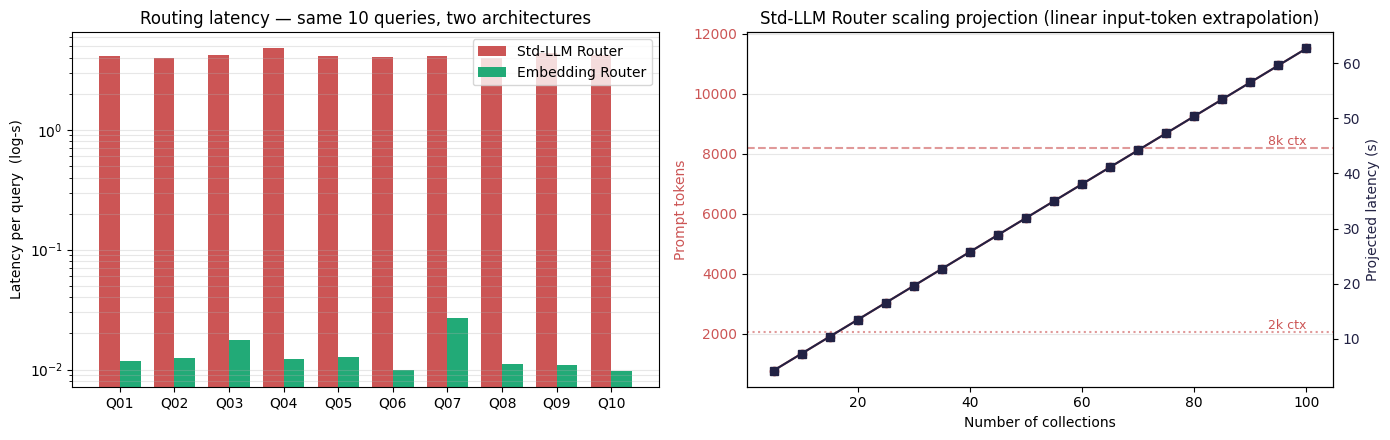

Saved: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step3_baseline_router.png


In [10]:
# Cell 10 — Charts: per-query latency + scaling curves

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) Per-query routing latency  —  log scale to keep both visible
x = np.arange(len(df))
w = 0.38
axes[0].bar(x - w/2, df["a_latency_s"], width=w, label="Std-LLM Router",  color="#C55")
axes[0].bar(x + w/2, df["b_latency_s"], width=w, label="Embedding Router", color="#2A7")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df["qid"])
axes[0].set_yscale("log")
axes[0].set_ylabel("Latency per query  (log-s)")
axes[0].set_title("Routing latency — same 10 queries, two architectures")
axes[0].grid(axis="y", alpha=0.3, which="both")
axes[0].legend()

# (2) Scaling projection
N_range = list(range(5, 101, 5))
tokens = [project(n)[0] for n in N_range]
lats   = [project(n)[1] for n in N_range]
ax2 = axes[1]
color1 = "#C55"; color2 = "#224"
ax2.plot(N_range, tokens, color=color1, marker="o", label="Prompt tokens")
ax2.set_xlabel("Number of collections")
ax2.set_ylabel("Prompt tokens", color=color1)
ax2.tick_params(axis="y", labelcolor=color1)
ax2.axhline(2048, color=color1, linestyle=":", alpha=0.6)
ax2.text(N_range[-1], 2048, "  2k ctx", color=color1, va="bottom", ha="right", fontsize=9)
ax2.axhline(8192, color=color1, linestyle="--", alpha=0.6)
ax2.text(N_range[-1], 8192, "  8k ctx", color=color1, va="bottom", ha="right", fontsize=9)
ax3 = ax2.twinx()
ax3.plot(N_range, lats, color=color2, marker="s", label="Projected latency (s)")
ax3.set_ylabel("Projected latency (s)", color=color2)
ax3.tick_params(axis="y", labelcolor=color2)
ax2.set_title("Std-LLM Router scaling projection (linear input-token extrapolation)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "ph3_step3_baseline_router.png")
plt.savefig(plot_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## Cell 11 — Export + summary

In [11]:
# Cell 11 — Persist results and print headline numbers

out = {
    "step": "Phase 3 - Step 3: Standard Router Baseline",
    "model": MODEL,
    "n_collections": len(COLLECTIONS),
    "n_queries": N,
    "collection_descriptions": {c: COLLECTIONS[c]["description"] for c in COLLECTIONS},
    "accuracy": {
        "std_llm_primary":  round(df["a_primary_ok"].sum() / N * 100, 1),
        "std_llm_loose":    round(df["a_accept_ok"].sum()  / N * 100, 1),
        "embedding_primary": round(df["b_primary_ok"].sum() / N * 100, 1),
        "embedding_loose":  round(df["b_accept_ok"].sum()  / N * 100, 1),
        "std_llm_hallucinations": int(df["a_hallucinated"].sum()),
    },
    "latency_s": {
        "std_llm":   {"mean": round(statistics.mean(la),3), "median": round(statistics.median(la),3), "max": round(max(la),3)},
        "embedding": {"mean": round(statistics.mean(lb),5), "median": round(statistics.median(lb),5), "max": round(max(lb),5)},
        "slowdown_mean": round(slowdown_mean, 0),
    },
    "context_bloat": {
        "prompt_tokens_at_5_collections": int(df["a_ctx_tokens"].iloc[0]),
        "description_tokens": desc_tokens,
        "description_share_pct": round(desc_tokens / df["a_ctx_tokens"].iloc[0] * 100, 0),
    },
    "scaling_projection": rows_scale,
    "per_query": [
        {k: (v if not isinstance(v,(list,tuple)) else list(v)) for k,v in r.items()}
        for r in rows
    ],
}

json_path = os.path.join(RESULTS_DIR, "ph3_step3_baseline_router.json")
csv_path  = os.path.join(RESULTS_DIR, "ph3_step3_baseline_router.csv")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False, default=str)
df.drop(columns=["acceptable"]).to_csv(csv_path, index=False)
print(f"Exported: {json_path}")
print(f"Exported: {csv_path}")
print(f"Exported: {plot_path}")

print("\n" + "=" * 72)
print("  STEP 3 SUMMARY")
print("=" * 72)
print(f"  Collections           : {len(COLLECTIONS)}")
print(f"  Queries               : {N}")
print()
print(f"  Std-LLM   primary     : {out['accuracy']['std_llm_primary']}%  "
      f"(loose {out['accuracy']['std_llm_loose']}%)   hallucinations: {out['accuracy']['std_llm_hallucinations']}")
print(f"  Embedding primary     : {out['accuracy']['embedding_primary']}%  "
      f"(loose {out['accuracy']['embedding_loose']}%)")
print()
print(f"  Std-LLM   latency     : {out['latency_s']['std_llm']['mean']:.3f}s mean, {out['latency_s']['std_llm']['max']:.3f}s max")
print(f"  Embedding latency     : {out['latency_s']['embedding']['mean']:.5f}s mean")
print(f"  Slowdown factor       : ~{out['latency_s']['slowdown_mean']:.0f}x")
print()
print(f"  Prompt size @ 5 colls : ~{out['context_bloat']['prompt_tokens_at_5_collections']} tokens")
print(f"    Descriptions share  : {out['context_bloat']['description_share_pct']:.0f}% of the prompt")
print("\n  Awaiting approval before Step 4 (Hierarchical Retrieval Agent).")

Exported: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step3_baseline_router.json
Exported: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step3_baseline_router.csv
Exported: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step3_baseline_router.png

  STEP 3 SUMMARY
  Collections           : 5
  Queries               : 999

  Std-LLM   primary     : 0.7%  (loose 0.9%)   hallucinations: 0
  Embedding primary     : 1.0%  (loose 1.0%)

  Std-LLM   latency     : 4.197s mean, 4.775s max
  Embedding latency     : 0.01358s mean
  Slowdown factor       : ~309x

  Prompt size @ 5 colls : ~789 tokens
    Descriptions share  : 72% of the prompt

  Awaiting approval before Step 4 (Hierarchical Retrieval Agent).
